# Neural recommender system 

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
rng = np.random.default_rng(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"


## 1. Task Definition

Given a dataset of implicit user-item interactions - no information on whether user liked or disliked the item - build three models as item recommenders:

1. Matrix Factorisation - Dot product of learned embeddings as a score
2. MLP-based recommender - learned embeddings fed into an MLP for nonlinear interactions 
3. NeuMF - combine both linear and non linear results
- Train with log loss adn evaluate by Hit@K

## 2. Data Analysis
- 55,375 rows, 2 columns: `user_id`, `item_id`


In [25]:
df = pd.read_csv('interactions.csv',low_memory=False)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55375 entries, 0 to 55374
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   user_id  55375 non-null  int64
 1   item_id  55375 non-null  int64
dtypes: int64(2)
memory usage: 865.4 KB


In [26]:
df.describe()

,user_id,item_id
count,55375.000000,55375.000000
mean,431.909725,333.916695
std,284.806639,275.753764
min,0.000000,0.000000
25%,150.000000,120.000000
50%,436.000000,261.000000
75%,670.000000,485.000000
max,941.000000,1446.000000


In [27]:
# df['user_id'].value_counts()
# df.isna().sum()
# df.duplicated().sum()
n_users = df['user_id'].nunique()
n_items = df['item_id'].nunique()
print(f"Number of uniques users : {n_users}")
print(f"Number of uniques items : {n_items}")

Number of uniques users : 942
Number of uniques items : 1447


In [28]:
# set(range(n_users))==set(df['user_id'])
# set(range(n_items))==set(df['item_id'])
print(f" Density : {len(df)/(n_users*n_items)*100 :.4f}")

 Density : 4.0625


count    942.000000
mean      58.784501
std       54.696664
min        3.000000
25%       19.000000
50%       39.500000
75%       80.750000
max      378.000000
dtype: float64

Top 10 users contribution % : 5.106997742663657
Count of users with (<5) contribution : 4


<Axes: xlabel='Number of interactions', ylabel='Frequency'>

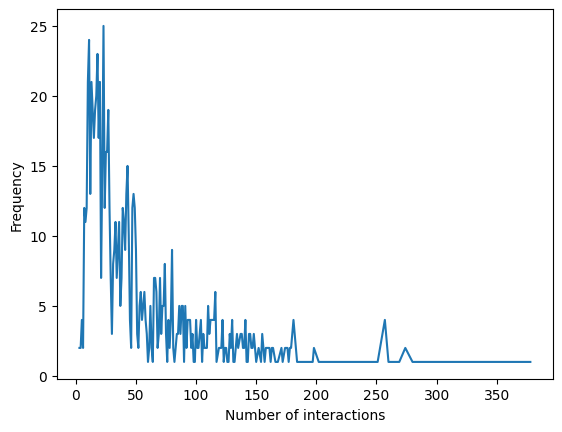

In [29]:
# User counts list to see different stats of users
# .size() would return a series like user_id - total interactions
user_counts = df.groupby('user_id').size()
# interactions by using users as rows and their total items used as the values
print(user_counts.describe())
print()
print(f"Top 10 users contribution % : {(user_counts.nlargest(10).sum()/user_counts.sum())*100}")
print(f"Count of users with (<5) contribution : {(user_counts<5).sum()}")
user_counts.value_counts().sort_index().plot(xlabel='Number of interactions',ylabel='Frequency') 

count    1447.000000
mean       38.268832
std        57.956847
min         1.000000
25%         3.000000
50%        13.000000
75%        47.500000
max       501.000000
dtype: float64

Top 10 items contribution % : 6.475846501128668
Count of items with (<5) contribution : 439


<Axes: xlabel='Number of interactions', ylabel='Frequency'>

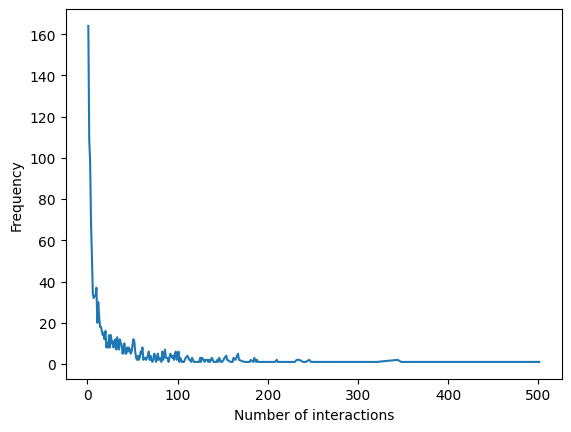

In [30]:
# Items count list with items as rows and number of users per item values as complex
item_counts = df.groupby('item_id').size()      
print(item_counts.describe())
print()
print(f"Top 10 items contribution % : {(item_counts.nlargest(10).sum()/item_counts.sum())*100}")
print(f"Count of items with (<5) contribution : {(item_counts<5).sum()}")        
item_counts.value_counts().sort_index().plot(xlabel='Number of interactions',ylabel='Frequency')                                              

## 2.1 Data Quality
| Check | Result |
|-------|--------|
| Nulls | 0 |
| Duplicate rows | 0 |
| Dtypes | int64 |
| Ranges | User 0-941, item 0-1446 (contiguous, 0 indexed) |

No preprocessing needed. ID's are already valid embedding indices with appropriate values

## 2.2 Scale
- 942 users, 1447 items
- 55,375 interactions
- Density: 4.06%- **highly sparse** `(942*1447/55375)*100`
  
## 2.3 Interaction distributions

**Users:**
| Metric | Value | 
|--------|-------|
| Mean | 58.784 |
| Median | 39.5 |
| std  | 54.7 |   
| Min  | 3    |
| Max  |   378|

- Only 4 users with <5 interactions - so cold start (new users with not enough data) is not a concern 
- Top 10 users - `5.1%` of interactions - no apparent long tail

**Items:**
| Metric | Value | 
|--------|-------|
| Mean | 38.3 |
| Median | 39.5 |
| std  | 57.9|   
| Min  | 1 |
| Max  |  501 |
- High standard deviation and 439 items with <5 interactions (~30%) - significant long tail
- Top 10 items - `6.5%` of interactions
- Items are more unevenly balanced than user

## 2.4 Considerations in modelling
1. **Sparsity(96%):**  Each user has seen on average less than 5% of items. So negative sampling is safe -> we basically want the model to learn that observed interactions should score higher than unobserved items - we are working with implicit feedback i.e users interacted with data and we take it as positive signal, - sparsity ensures that sampled negatives are rarely actual positives, so the training signal remains mostly correct even though unobserved data mixes unseen and disliked items. 
   - The model only needs to learn relative preference not true like dislike
   - Even if unseen + good they behave like noise not bias
2. **Item long tail:** 439 items have < 5 interactions. Their embeddings will be undertrained.  MLP cant help here cause its a data coverage problem not model problem.
3. **IDs are 0-indexed and contiguous**: `nn.Embedding(942, d)` and `nn.Embedding(1447, d)` work directly without any remapping.

# 3. Training models

## 3.1 Test, train and validation data

1. `ShuffleSplit()` via `test_train_split()` could lead to the following problems:
    - Uneven test sample distribution skewed by active users
    - May leave out some users completely for testing
2. As done in the reference material, I am using leave-one-out per user for test and validation split for the following reasons:
    - Even distribution among all users
    - Also alligns with Hit@K evaluation metric / ranking observed vs unobserved
3. Single test-train-validation split instead of cross validation because:
    - Cross validation is computationally expensive with forming the ranking evaluation multiple times
    - Leave-one-out already provides stable per user evaluation


In [31]:
# Leave-one-out
def leave_one_out_split(data):
    groups = data.groupby('user_id')
    test_df = groups.sample(1,random_state=SEED)
    train_df = data.drop(test_df.index)
    return test_df,train_df

test_df,train_df = leave_one_out_split(df)
validation_df,train_df = leave_one_out_split(train_df)

# set(train_df.index).isdisjoint(test_df.index)
# set(train_df.index).isdisjoint(validation_df.index)
# set(test_df.index).isdisjoint(validation_df.index)

## 3.2 Negative sampling

The dataset only has positive interactions. Training needs negative examples as well for properly learning binary classifying items as like or dislike per user.

- For each (user,item) positive pair sample `n_samples` items the user has never interacted with and label them 0.
- There will be some noise as these contain (unseen and seen+disliked) but we can use this method for reasons mentioned in  `#2.4`
  
**Implementation:** 
- build a map of all `(user_id,item_id)`  pairs for $O(1)$ membership check. 
- for each user sample uniformly from all items and reject if in their interaction set
- negative samples are only sampled for training not validation or testing. As in evaluation Hit@K evaluation has its own sampling procedure for negatives.

In [32]:
# Bulid a map for the interacted map items for fast lookup
# groupby returns dataframes for each group iterable over user,items from which 
# item column is selected which gives grouped series which  is turned to a set of unique items per user and to dictionary for O(1) lookup
user_pos_items = df.groupby('user_id')['item_id'].agg(set).to_dict()

In [33]:
# Negative sampling
def negative_sampling(train_df,num_items,n_samples=1):
    # rows of the final dataset with positives + negatives
    rows = []
    for user,group in train_df.groupby('user_id'):
        # positive interactions for that user present in train_df
        pos_item = set(group['item_id'])
        # all positive interactions for that user
        full_pos = user_pos_items[user]

        # add the positives 
        for i in pos_item:
            rows.append((user,i,1))

        # sample negatives - n_samples per positive item in training set
        n_needed = n_samples * len(pos_item)

        negatives = []
        while len(negatives) < n_needed:
            # sample number of needed of items at once
            candidates = np.random.randint(0,num_items,n_needed-len(negatives))
            # select non true positives
            for j in candidates:
                if j not in full_pos:
                    negatives.append(j)
                if len(negatives)>=n_needed:
                    break
        # add the negatives 
        i=0
        for _ in pos_item:
            for _ in range(n_samples):
                rows.append((user,negatives[i],0))
                i+=1
    # shuffle the rows (frac=1 -> 100% rows) cause theres explicit structure or pos->neg->pos here  
    return pd.DataFrame(rows,columns=["user_id","item_id","label"]).sample(frac=1).reset_index(drop=True)   

In [ ]:
# negative sampling checks
print(f"Number of (user,item) pairs in train split : {train_df.count()}")
n_negative_samples = 3
train_df_neg = negative_sampling(train_df,num_items=n_items,n_samples=n_negative_samples)
print(f"Number of entries added per pair should be {n_negative_samples+1} : {train_df_neg['user_id'].count()/train_df['user_id'].count()}")
# train_df_neg[train_df_neg['user_id']==1]
print(f"\nFinal train_df shape : {train_df_neg.shape}")
print(f"\nLabel value counts : \n{train_df_neg['label'].value_counts()}")
for i in train_df_neg['label'].unique():
    print(train_df_neg[train_df_neg['label']==i].sample(1))


Number of (user,item) pairs in train split : user_id    53491
item_id    53491
dtype: int64
Number of entries added per pair should be 4 : 4.0

Final train_df shape : (213964, 3)

Label value counts : 
label
0    160473
1     53491
Name: count, dtype: int64
       user_id  item_id  label
91804      614      832      0
        user_id  item_id  label
207613      165      151      1


### Dataset and Dataloader
Wrap the processed data into PyTorch `Dataset` class as map from keys to data samples with its custom `__getitem__` for fetching data sample for a given key and `__len__`. 
* Since our dataset is properly indexed with integers we can use `DataLoader` with it which constructs an index sampler that gives integer indices. If it was a map-style dataset a custom `Sampler` would also be needed

In [35]:
class InteractionDataset(Dataset):
    def __init__(self,df):
        self.users = torch.tensor(df['user_id'].values)
        self.items = torch.tensor(df['item_id'].values)
        self.labels = torch.tensor(df['label'].values).float()
    def __len__(self):
        return len(self.users)
    def __getitem__(self, index):
        return (self.users[index],self.items[index],self.labels[index])

train_loader = DataLoader(InteractionDataset(train_df_neg),batch_size=128,shuffle=True)

## 3.3 Embeddings and model structures

- **Embeddings:** An embedding  is a parameter matrix $E \in \mathbb{R}^{N \times d}$ where row $i$ is the learned vector for item $i$.
    - Its a table where using backprop the rows corresponding to items in the current batc recieve gradient updates.
    - Its equivalent to one-hot encoding followed by a linear layer
    - Embeddings are learnt jointly with the rest of the model - they start random and are updated to minimise BCE loss. 
    - At end geometrically close embeddings correspond to users/items with simlar interaction patters

## 1. Matrix Factorisaiton (MF)
- MF assumes that user-item interactions can be represented as a dot product in  a latent space formed by :
    - User embedding : $p_u \in \mathbb{R}^k$
    - Item embedding : $q_i \in \mathbb{R}^k$
  
Prediction is : $\hat{y_ui} = p_u^T q_i$
- This outptus a score which shows linear interaction between items and users in a learned latent space (embeddings)
- Each dimension contributes independently i.e no cross-feature interactions / nonlinear dependencies

## Hit@K Evaluation

Hit@K is a ranking metric. For each user in the test set:
- Take their 1 held-out positive item
- Sample `num_neg` items they have never interacted with
- Score all `num_neg + 1` items using the model
- A hit occurs if the positive item appears in the top-K ranked items

$\text{Hit@K} = \frac{\text{number of hits}}{\text{total test users}}$

This directly measures if the model can rank a known relevant item
above random noise (the negative samples), K=10 with 100 negatives is the standard protocol from the NCF paper.
Harder variants: decrease K or increase num_neg.

In [ ]:
def hit_at_k(model,test_df,full_df,device=device,K=10,num_neg=100):
    model.eval()
    model.to(device)

    hits = 0
    tot = len(test_df)
    n_items = full_df['item_id'].nunique()
    # disable autograd / other features tracking while evaluation 
    with torch.no_grad():
        for user,group in test_df.groupby('user_id'):
            # positive items for that user in test_df
            pos_items = list(group['item_id'])
            # positive items for that user in full df
            full_pos = user_pos_items[user]
            
            # for each positive item for that user
            for pos_item in pos_items:
                # list of negatives
                negatives = []
                # same method as negative_sampling 
                while len(negatives) <num_neg:
                    candidates = np.random.randint(0,n_items,num_neg-len(negatives))
                    for j in candidates:
                        if j not in full_pos:
                            negatives.append(j)
                        if len(negatives) >= num_neg:
                            break
                # positive item is index 0
                items = torch.tensor([pos_item] + negatives,device=device)
                users = torch.tensor([user]*(num_neg+1),device=device)
                # calculate scores as a forward pass from trained model
                # since eval mode and no_grad this doesnt train the model
                scores = model(users,items)
                _, top_k = torch.topk(scores,K)
                
                # positive is index 0
                if (top_k==0).any():
                    hits +=1
    return hits/tot     

In [ ]:
class MF(nn.Module):
    def __init__(self,n_users,n_items
                ,emb_dim=32
                ,use_item_bias=True):
        # initliase parent module to track parameters properly 
        super().__init__()
        # emebeddings of shape (number, emb_dim)
        self.user_emb = nn.Embedding(num_embeddings=n_users,embedding_dim=emb_dim)
        self.item_emb= nn.Embedding(num_embeddings=n_items,embedding_dim=emb_dim)

        self.use_item_bias = use_item_bias
        # optional global item bias
        if use_item_bias:
            self.item_bias = nn.Embedding(n_items,1)
            nn.init.zeros_(self.item_bias.weight)

        # normal_ -> modify the tensor in place with values from normal distribution
        # initialise from a small variance normal distribution 
        nn.init.normal_(self.user_emb.weight,std=0.1)
        nn.init.normal_(self.item_emb.weight,std=0.1)

        # loss and validation tracking for plotting later
        self.loss_history = []
        self.val_history = []
    def forward(self,user,item):
        # get the vectors for users and items
        p_u = self.user_emb(user)
        q_i = self.item_emb(item)
        # elementwise multiply + sum across embedding dimension
        score = (p_u *q_i).sum(dim=1)
        
        if self.use_item_bias:
            # squeeze(-1) turns (n,1) to (n,) as loss expects a single value per sample
            score += self.item_bias(item).squeeze(-1)
        # returns raw score
        return score
    
    def fit(self
            ,loader
            ,lr=1e-3
            ,optim=torch.optim.Adam
            ,crit=nn.BCEWithLogitsLoss
            ,epochs=10
            ,device="cpu"
            ,val_df = None
            ,full_df  = None
            ,K=10
            , **kwargs  # for L2 weight decay or other optimiser specific args
            ):
        
        # move model parameters to specified device 
        self.to(device)
        self.train()

        # initialise optimizer and criterion method 
        optimizer = optim(self.parameters(),lr=lr,**kwargs)
        # bce with logit loss applies sigmoid to map raw scores(logits) to probabilities then apply BCE as it expects probabilites
        criterion = crit()

        best_metric = -np.inf
        for epoch in range(epochs):
            # tracking losses
            epoch_loss = 0.0
            batch_count = 0
            for user,item,label in loader:
                # all the objects involved in computation should be on the same device
                user = user.to(device)
                item = item.to(device)
                label = label.to(device)
                # clear previous gradients to avoid accumulation
                optimizer.zero_grad()
                # forward pass - compute predicted score 
                score = self.forward(user,item)
                # compute loss against actual label
                loss = criterion(score,label)
                # backpropogate to get gradients
                loss.backward()
                # update parameters with the gradients
                optimizer.step()                
                epoch_loss += loss.item()
                batch_count += 1
            # avg epoch loss
            epoch_loss = epoch_loss/batch_count
            self.loss_history.append(epoch_loss)
            
            # print validation periodically for early stopping when needed
            if val_df is not None  and epoch%5==0:
                val_metric = hit_at_k(self, val_df, full_df, K=K)
                self.val_history.append(val_metric)

                print(f"Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Val@{K}: {val_metric:.4f}")

                if val_metric > best_metric:
                    best_metric = val_metric
    def predict(self,user,item):
        self.eval()

        if not isinstance(user,torch.Tensor):
            user = torch.Tensor(user)
        if not isinstance(item,torch.Tensor):
            item = torch.Tensor(item)

        with torch.no_grad():
            return torch.sigmoid(self.forward(user,item))        

In [16]:
model = MF(
    n_users=n_users,
    n_items=n_items,
    emb_dim=16,
    use_item_bias=False
)
# changing emb_dim, epochs, lr, and testing with validation for hyperparameter tuning
model.fit(
    train_loader,
    epochs=23,
    lr=1e-3,
    device=device,
    val_df=validation_df,
    full_df=df,
    K=10
)

test_hit = hit_at_k(model, test_df, df, K=10)
print(f"\nTest Hit@10: {test_hit:.4f}")

Epoch 1 | Loss: 0.6819 | Val@10: 0.4873
Epoch 6 | Loss: 0.3390 | Val@10: 0.6433
Epoch 11 | Loss: 0.2757 | Val@10: 0.7240
Epoch 16 | Loss: 0.2411 | Val@10: 0.7219
Epoch 21 | Loss: 0.2194 | Val@10: 0.7282

Test Hit@10: 0.7144


## 2. MLP Recommender

Instead of a dot product, learn a nonlinear interaction function:
$\hat{y}_{ui} = \text{MLP}([p_u \| q_i])$

Concatenation gives the MLP access to all user and item features jointly -
it can learn nonlinear interactions and feature crosses that dot product cannot.
- From the loader we get a set of (user, item, label) interactions, so matrix shapes evolve as:

 -> Users, Items  (128,) (128,)

 -> UserEmb, ItemEmb (128,32) (128,32)

 -> Concat (128,64)
* Row-wise:
row[k] = [u_k1, u_k2, ..., u_k32,  i_k1, i_k2, ..., i_k32]

In [ ]:
class MLPRecommender(nn.Module):
    def __init__(self,n_users,n_items
                ,emb_dim = 32
                ,hidden=[64,32]
                ,batch_norm=False
                ,drop_rate=0.0):
        super().__init__()
        self.user_emb = nn.Embedding(n_users,emb_dim)
        self.item_emb = nn.Embedding(n_items,emb_dim)
        nn.init.normal_(self.user_emb.weight,std=0.1)
        nn.init.normal_(self.item_emb.weight,std=0.1)

        layers = []
        # since on concatenation the shape would become (128,64)
        current_dim = emb_dim*2
        # add hidden layers with regularisations if specified
        for h in hidden:
            layers.append(nn.Linear(current_dim,h))
            if batch_norm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if drop_rate > 0:
                layers.append(nn.Dropout(drop_rate))
            current_dim = h 
        # final output should be a score (1,)
        layers.append(nn.Linear(current_dim,1))
        self.mlp = nn.Sequential(*layers)

        self.loss_history = []
        self.val_history = []
    def forward(self, user, item):
        x = torch.cat([self.user_emb(user), self.item_emb(item)], dim=1)
        return self.mlp(x).squeeze(-1)
    # fit and predict remain the same as MF 
    def fit(self
        ,loader
        ,lr=1e-3
        ,optim=torch.optim.Adam
        ,crit=nn.BCEWithLogitsLoss
        ,epochs=10
        ,device="cpu"
        ,val_df = None
        ,full_df  = None
        ,K=10
        , **kwargs
        ):
    
        self.to(device)
        self.train()
        optimizer = optim(self.parameters(),lr=lr, **kwargs)
        criterion = crit()
        best_metric = -np.inf
        for epoch in range(epochs):

            epoch_loss = 0.0
            batch_count = 0
            for user,item,label in loader:
                user = user.to(device)
                item = item.to(device)
                label = label.to(device)
                optimizer.zero_grad()
                score = self.forward(user,item)
                loss = criterion(score,label)

                loss.backward()

                optimizer.step()                
                epoch_loss += loss.item()
                batch_count += 1
            epoch_loss = epoch_loss/batch_count
            self.loss_history.append(epoch_loss)

            if val_df is not None  and epoch%5==0:
                val_metric = hit_at_k(self, val_df, full_df, K=K)
                self.val_history.append(val_metric)

                print(f"Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Val@{K}: {val_metric:.4f}")

                if val_metric > best_metric:
                    best_metric = val_metric
    def predict(self,user,item):
        self.eval()

        if not isinstance(user,torch.Tensor):
            user = torch.Tensor(user)
        if not isinstance(item,torch.Tensor):
            item = torch.Tensor(item)

        with torch.no_grad():
            return torch.sigmoid(self.forward(user,item)) 

In [18]:
mlp_model = MLPRecommender(n_users,
                           n_items,
                           emb_dim=32,
                           hidden=[64,16]
                           )
mlp_model.fit(train_loader
              ,lr=1e-2
              ,optim=torch.optim.Adam
              ,crit=nn.BCEWithLogitsLoss
              ,epochs=14
              ,val_df=validation_df
              ,full_df=df
              ,device=device
            #   ,weight_decay=1e-3
              )

test_hit_mlp = hit_at_k(mlp_model,test_df,df,K=10)
print(f"\nTest Hit@10: {test_hit_mlp:.4f}")

Epoch 1 | Loss: 0.4116 | Val@10: 0.5658
Epoch 6 | Loss: 0.3114 | Val@10: 0.7463
Epoch 11 | Loss: 0.2715 | Val@10: 0.7834

Test Hit@10: 0.7580


## 3. NeuMF - Neural Matrix Factorisation

MF is too rigid - dot product cant represent interactions between different latent effects without expanding capacity. MLP captures complex patterns but needs more data to justify the extra capacity. NeuMF runs both in parallel with separate embedding tables:

- MF path: element-wise product of embeddings, keeps full vector (B, mf_dim)
- MLP path: concatenate embeddings -> MLP layers -> last hidden (B, h_last)
- Predict layer: concat both -> linear -> scalar score

Separate embedding tables because dot product and concatenation impose different geometric constraints on the latent space - sharing would compromise both paths.

In [ ]:
class NeuMF(nn.Module):
    def __init__(self,n_users,n_items
                ,mf_dim=32
                ,mlp_dim=32
                ,hidden=[64,32]
                ):
        super().__init__()
        # MF embeddings
        self.mf_user = nn.Embedding(n_users,mf_dim)
        self.mf_item = nn.Embedding(n_items,mf_dim)
        # MLP embeddings
        self.mlp_user = nn.Embedding(n_users, mlp_dim)
        self.mlp_item = nn.Embedding(n_items, mlp_dim)
        # initialise all
        for emb in [self.mf_item,self.mf_user,self.mlp_item,self.mlp_user]:
            nn.init.normal_(emb.weight,std=0.1)

        # mlp sequence setup but instead of final being a scalar merge to anoher layer with MF results
        layers = []
        current_dim = mlp_dim *2
        for h in hidden:
            layers.append(nn.Linear(current_dim,h))
            layers.append(nn.ReLU())
            current_dim = h
        self.mlp = nn.Sequential(*layers)

        self.predict_layer = nn.Linear(mf_dim+hidden[-1],1)
        self.loss_history = []
        self.val_history = []
    
    def forward(self,user,item):
        #  MF forward
        mf_out = self.mf_user(user) * self.mf_item(item)
        # MLP forward
        mlp_in = torch.cat([self.mlp_user(user),self.mlp_item(item)],dim=1)
        mlp_out = self.mlp(mlp_in)
        # Concatenate both across embedding dimension
        x = torch.cat([mf_out,mlp_out],dim=1)
        # output scores as (scores,) with squeeze
        out = self.predict_layer(x).squeeze(-1)
        return out
    # same fit and predict
    def fit(self
        ,loader
        ,lr=1e-3
        ,optim=torch.optim.Adam
        ,crit=nn.BCEWithLogitsLoss
        ,epochs=10
        ,device="cpu"
        ,val_df = None
        ,full_df  = None
        ,K=10
        , **kwargs
        ):
    
        self.to(device)
        self.train()
        optimizer = optim(self.parameters(),lr=lr, **kwargs)
        criterion = crit()
        best_metric = -np.inf
        for epoch in range(epochs):

            epoch_loss = 0.0
            batch_count = 0
            for user,item,label in loader:
                user = user.to(device)
                item = item.to(device)
                label = label.to(device)
                optimizer.zero_grad()
                score = self.forward(user,item)
                loss = criterion(score,label)

                loss.backward()

                optimizer.step()                
                epoch_loss += loss.item()
                batch_count += 1
            epoch_loss = epoch_loss/batch_count
            self.loss_history.append(epoch_loss)

            if val_df is not None  and epoch%5==0:
                val_metric = hit_at_k(self, val_df, full_df, K=K)
                self.val_history.append(val_metric)

                print(f"Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Val@{K}: {val_metric:.4f}")

                if val_metric > best_metric:
                    best_metric = val_metric
    def predict(self,user,item):
        self.eval()

        if not isinstance(user,torch.Tensor):
            user = torch.Tensor(user)
        if not isinstance(item,torch.Tensor):
            item = torch.Tensor(item)

        with torch.no_grad():
            return torch.sigmoid(self.forward(user,item))      

In [ ]:
neumf_model = NeuMF(
    n_users=n_users,
    n_items=n_items,
    mf_dim=24,
    mlp_dim=24,
    hidden=[32,16]
)

neumf_model.fit(
    train_loader,
    epochs=7,
    lr=5*1e-3,
    device=device,
    val_df=validation_df,
    full_df=df,
    K=10
)

test_hit = hit_at_k(neumf_model, test_df, df, K=10)
print(f"\nTest Hit@10: {test_hit:.4f}")

Epoch 1 | Loss: 0.3956 | Val@10: 0.6868
Epoch 6 | Loss: 0.1660 | Val@10: 0.6868

Test Hit@10: 0.7155


## 4. Bayesian Personalised Ranking (BPR)

$\text{BPR} = \sum_{(u,i,j)} \ln \sigma(\hat{y}_{ui} - \hat{y}_{uj})$

Each training sample is a triplet $(u, i, j)$ - user, positive item, negative item. The loss pushes $\hat{y}_{ui} - \hat{y}_{uj} > 0$, which is directly what Hit@K measures.

This means:
- No need for explicit 0/1 labels
- Loss is defined over pairs of items, not individual items
- Gradient updates are driven by the margin between positive and negative scores, not absolute values

With BCE + negative sampling the model is implicitly doing something similar, but BPR makes the relative ranking objective explicit. On sparse implicit feedback data with a ranking evaluation metric, BPR is a better-aligned objective.

### Triplet Dataset

In [ ]:
class TripletDataset(Dataset):
    def __init__(self, train_df, num_items, n_neg=3):
        # build user -> positive items map from train only
        user_pos = train_df.groupby('user_id')['item_id'].apply(set).to_dict()
        
        triplets = []
        # for each user,pos items group
        for user, pos_items in user_pos.items():
            # for each pos item with that group
            for pos in pos_items:
                # sample n_neg negatives which arent true positives
                for _ in range(n_neg):
                    neg = np.random.randint(0, num_items)
                    while neg in user_pos_items[user]:  
                        neg = np.random.randint(0, num_items)
                    triplets.append((user, pos, neg))
        # get the users , pos items and neg items as tensors 
        triplets = np.array(triplets)
        self.users = torch.tensor(triplets[:, 0])
        self.pos   = torch.tensor(triplets[:, 1])
        self.neg   = torch.tensor(triplets[:, 2])
    
    def __len__(self):
        return len(self.users)
    
    def __getitem__(self, idx):
        return self.users[idx], self.pos[idx], self.neg[idx]

bpr_loader = DataLoader(TripletDataset(train_df, n_items, n_neg=4), batch_size=128, shuffle=True)

### BPR Model

In [ ]:
class BPRRecommender(nn.Module):
    def __init__(self, n_users, n_items, emb_dim=32):
        super().__init__()
        # same init for embeddings
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)
        nn.init.normal_(self.user_emb.weight, std=0.1)
        nn.init.normal_(self.item_emb.weight, std=0.1)

        self.loss_history = []
        self.val_history = []

    def forward(self, user, item):
        # returns score per (user, item) pair - used in hit_at_k
        return (self.user_emb(user) * self.item_emb(item)).sum(dim=1)

    def bpr_loss(self, user, pos, neg):
        u  = self.user_emb(user)
        pi = self.item_emb(pos)
        ni = self.item_emb(neg)
        # loss as defined for BPR 
        diff = (u * pi).sum(dim=1)-(u * ni).sum(dim=1)
        loss = -torch.log(torch.sigmoid(diff)).mean()

        return loss
    # same fit except custom BPR loss
    def fit(self, loader
            ,lr=1e-3
            ,epochs=10
            ,device='cpu'
            ,val_df=None
            ,full_df=None
            ,K=10):
        self.to(device)
        self.train()
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        best_metric = -np.inf

        for epoch in range(epochs):
            epoch_loss = 0.0
            batch_count = 0
            for user,pos,neg in loader:
                user,pos,neg = user.to(device), pos.to(device), neg.to(device)
                optimizer.zero_grad()
                loss=self.bpr_loss(user,pos,neg)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
                batch_count += 1

            epoch_loss /= batch_count
            self.loss_history.append(epoch_loss)

            if val_df is not None and epoch % 5 == 0:
                val_metric = hit_at_k(self, val_df, full_df, K=K)
                self.val_history.append(val_metric)
                print(f"Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Val@{K}: {val_metric:.4f}")
                if val_metric > best_metric:
                    best_metric = val_metric

    def predict(self, user, item):
        self.eval()
        if not isinstance(user, torch.Tensor):
            user = torch.tensor(user)
        if not isinstance(item, torch.Tensor):
            item = torch.tensor(item)
        with torch.no_grad():
            return self.forward(user, item)

In [40]:
bpr_model = BPRRecommender(n_users, n_items, emb_dim=32)
bpr_model.fit(
    bpr_loader,
    lr=1e-3,
    epochs=10,
    device="cuda",
    val_df=validation_df,
    full_df=df,
    K=10
)

test_hit_bpr = hit_at_k(bpr_model, test_df, df, K=10)
print(f"\nTest Hit@10: {test_hit_bpr:.4f}")

Epoch 1 | Loss: 0.5807 | Val@10: 0.5648
Epoch 6 | Loss: 0.1100 | Val@10: 0.7431

Test Hit@10: 0.7611


## 5. Plots

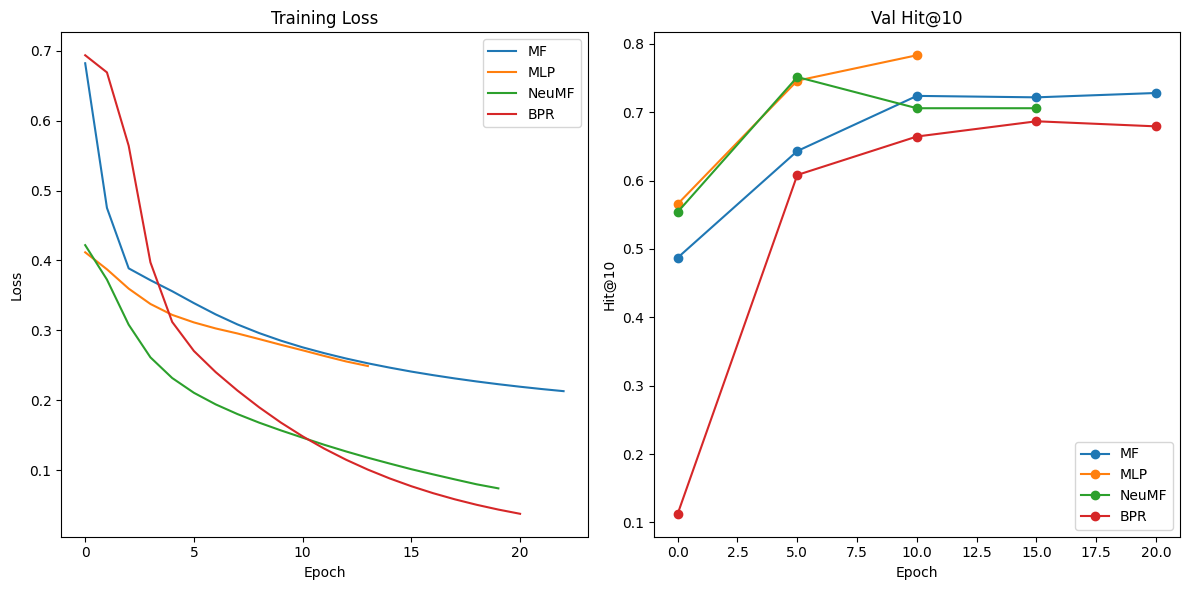

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(12,6))

# loss curves
for m, label in [(model, 'MF'), (mlp_model, 'MLP'), (neumf_model,'NeuMF'), (bpr_model, 'BPR')]:
    ax[0].plot(range(len(m.loss_history)),m.loss_history,label=label)
ax[0].set_title('Training Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

# val hit@k curves (only if val was run)
for m, label in [(model, 'MF'), (mlp_model, 'MLP'), (neumf_model,'NeuMF'),(bpr_model, 'BPR')]:
    if m.val_history:
        epochs_logged = list(range(1, len(m.val_history)*5, 5))[:len(m.val_history)]
        ax[1].plot(epochs_logged, m.val_history, marker='o', label=label)
ax[1].set_title('Val Hit@10')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Hit@10')
ax[1].legend()

plt.tight_layout()
plt.show()